# Import Libraries
---

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Load Cleaned Data
---

In [89]:
df = pd.read_csv(r'data\Ames_Cleaned_data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [90]:
# Split by data type
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Identify zero-variance / useless columns immediately
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
high_null_cols = df.columns[df.isna().mean() > 0.25].tolist()

print(f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")
print(f"Constant/Useless: {len(constant_cols)} | >25% Missing: {len(high_null_cols)}")

Numeric: 37 | Categorical: 37
Constant/Useless: 0 | >25% Missing: 0


In [91]:
print('Constant/Useless Columns')
print('='*30)
for constant_col in constant_cols:
    print(f'Column Name: [{constant_col}]')
    print(f'Unique Values of {constant_col}: {df[constant_col].unique()}')
    print('-'*30)

Constant/Useless Columns


In [92]:
df.drop(columns=constant_cols, inplace=True)

In [93]:
# Split by data type
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")

Numeric: 37 | Categorical: 37


In [94]:
import dtale
dtale.show(df)

<Axes: >

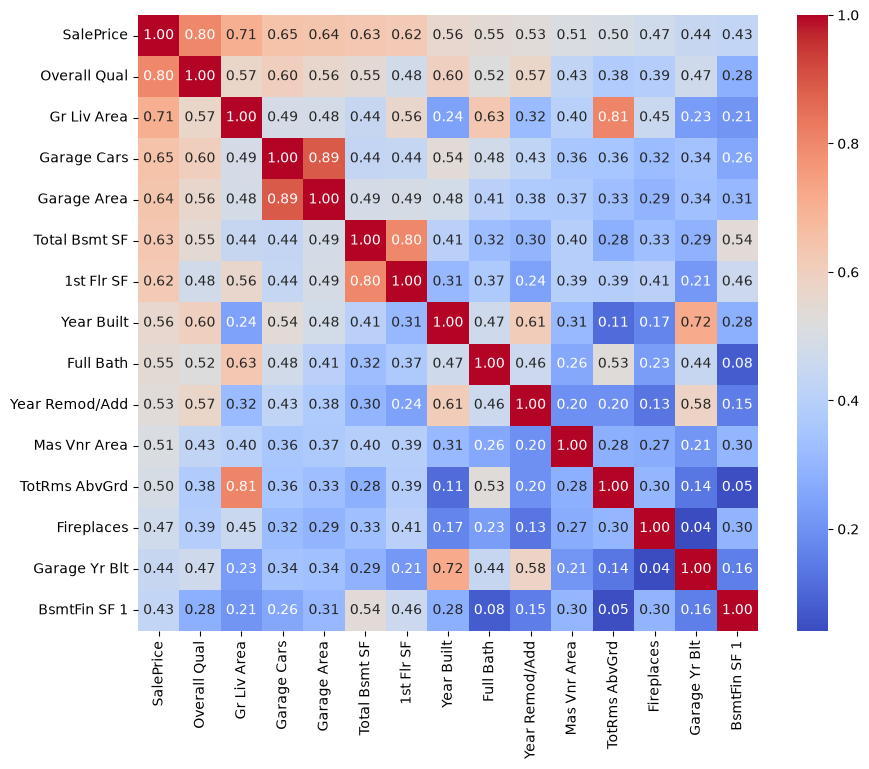

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to features correlated with target
target_col = 'SalePrice'
corr = df[num_cols].corr()
top_corr = corr[target_col].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")

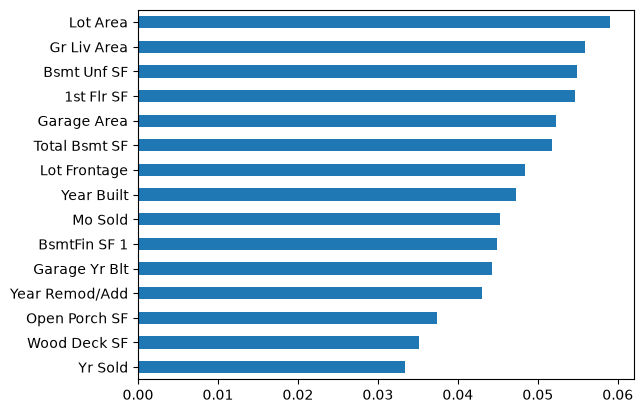

In [96]:
from sklearn.ensemble import RandomForestClassifier

X = df[num_cols].drop(columns=['SalePrice'])
y = df.loc[X.index, target_col]

rf = RandomForestClassifier(n_estimators=50).fit(X, y)
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot top 15 features only
importance.head(15).plot(kind='barh').invert_yaxis()

In [97]:
def profile_df(data):
    summary = pd.DataFrame({
        'Data Type': data.dtypes,
        'Null Count': data.isna().sum(),
        'Null %': (data.isna().mean() * 100).round(2),
        'Unique Values': data.nunique(),
        'Sample Value': data.bfill().iloc[0] if not data.empty else None
    })
    return summary

summary = profile_df(df)
summary

,Data Type,Null Count,Null %,Unique Values,Sample Value
MS SubClass,int64,0,0.0,16,20
MS Zoning,object,0,0.0,7,RL
Lot Frontage,float64,0,0.0,129,141.0
Lot Area,int64,0,0.0,1960,31770
Street,object,0,0.0,2,Pave
...,...,...,...,...,...
Mo Sold,int64,0,0.0,12,5
Yr Sold,int64,0,0.0,5,2010
Sale Type,object,0,0.0,10,WD
Sale Condition,object,0,0.0,6,Normal
